In [ ]:
# Load trained model and held-out test set for business analysis

import os

import joblib
import numpy as np
import pandas as pd

MODEL_PATH = "../models/telco_churn_model.joblib"

model = joblib.load(MODEL_PATH)

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Model and test data loaded successfully.")

Model and test data loaded successfully.


In [ ]:
# Rank features by built-in importance to surface top churn drivers

model_estimator = model

if hasattr(model_estimator, "named_steps"):
    model_estimator = model_estimator.named_steps["model"]

if hasattr(model_estimator, "feature_importances_"):

    importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance": model_estimator.feature_importances_
    })

    importance_df = (
        importance_df
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    print("Top churn drivers:")
    display(importance_df.head(10))

Top churn drivers:


,feature,importance
0,numerical__tenure,18.325078
1,categorical__contract_Month-to-month,13.792915
2,numerical__monthlycharges,12.498914
3,numerical__totalcharges,9.058343
4,categorical__contract_Two year,5.839967
5,categorical__onlinesecurity_No,5.030110
6,categorical__internetservice_Fiber optic,3.946755
7,categorical__paymentmethod_Electronic check,3.613806
8,categorical__techsupport_No,3.208076
9,categorical__paperlessbilling_No,1.890266


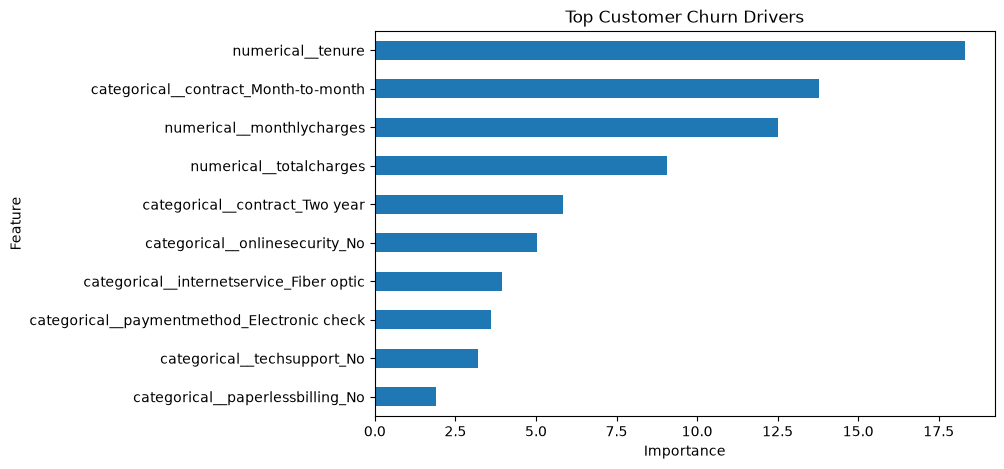

In [ ]:
# Visualize the top 10 churn drivers for stakeholder communication

import matplotlib.pyplot as plt

top_drivers = importance_df.head(10)

top_drivers.plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8, 5),
    legend=False
)

plt.title("Top Customer Churn Drivers")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

**Key takeaway from the top drivers chart:** Churn is driven primarily by contract and tenure economics rather than service quality alone. `tenure`, `contract_Month-to-month`, `monthlycharges`, and `totalcharges` are the four strongest predictors, indicating that newer customers on flexible, higher-cost, month-to-month plans are the most likely to leave. Secondary drivers — lack of `online security`, `fiber optic` internet, `electronic check` payment, and no `tech support` — point to service and payment friction as compounding risk factors. Retention efforts should prioritize converting month-to-month customers to longer-term contracts and reinforcing value during the early tenure period.

In [ ]:
# Segment customers into risk tiers based on predicted churn probability

risk_df = X_test.copy()

risk_df["churn_probability"] = y_proba
risk_df["predicted_churn"] = y_pred

risk_df["risk_segment"] = pd.cut(
    risk_df["churn_probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

risk_summary = (
    risk_df["risk_segment"]
    .value_counts()
    .rename_axis("Risk Segment")
    .reset_index(name="Customers")
)

risk_summary["Percentage"] = (
    risk_summary["Customers"] / len(risk_df) * 100
).round(2)

risk_summary

,Risk Segment,Customers,Percentage
0,Low Risk,679,64.24
1,Medium Risk,252,23.84
2,High Risk,126,11.92


In [ ]:
# Surface the highest-probability churners for targeted outreach

high_risk_customers = (
    risk_df[
        risk_df["risk_segment"] == "High Risk"
    ]
    .sort_values("churn_probability", ascending=False)
)

high_risk_customers.head(10)

,numerical__seniorcitizen,numerical__tenure,numerical__monthlycharges,numerical__totalcharges,categorical__gender_Female,categorical__gender_Male,categorical__partner_No,categorical__partner_Yes,categorical__dependents_No,categorical__dependents_Yes,...,categorical__contract_Two year,categorical__paperlessbilling_No,categorical__paperlessbilling_Yes,categorical__paymentmethod_Bank transfer (automatic),categorical__paymentmethod_Credit card (automatic),categorical__paymentmethod_Electronic check,categorical__paymentmethod_Mailed check,churn_probability,predicted_churn,risk_segment
421,-0.438147,-1.277041,1.008575,-0.963932,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.936628,1,High Risk
474,2.282338,-1.277041,0.997001,-0.964085,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.929717,1,High Risk
112,2.282338,-1.033572,1.134234,-0.715127,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.910455,1,High Risk
1044,-0.438147,-1.277041,0.469565,-0.971047,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.899600,1,High Risk
252,-0.438147,-1.195884,1.190450,-0.861573,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.897645,1,High Risk
585,-0.438147,-1.277041,0.403428,-0.971920,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.896435,1,High Risk
476,-0.438147,-1.277041,0.315798,-0.973077,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.885238,1,High Risk
200,-0.438147,-1.195884,1.046603,-0.878182,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.880823,1,High Risk
865,-0.438147,-1.074150,1.334296,-0.767616,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.861395,1,High Risk
631,2.282338,-0.992994,1.163995,-0.609014,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.857571,1,High Risk


Low Risk       → Maintain current service
Medium Risk    → Monitor and engage
High Risk      → Prioritize retention intervention

In [ ]:
# Map churn drivers to concrete, actionable business recommendations

recommendations = pd.DataFrame({
    "Churn Driver": [
        "High-risk customer segment",
        "Short customer tenure",
        "High monthly charges",
        "Month-to-month contracts",
        "Service/payment friction"
    ],
    "Recommended Action": [
        "Prioritize proactive retention campaigns",
        "Strengthen onboarding and early-life engagement",
        "Offer targeted value-based plans or incentives",
        "Encourage longer-term contracts with appropriate benefits",
        "Improve support, payment experience, and service reliability"
    ],
    "Business Objective": [
        "Reduce preventable churn",
        "Increase early customer retention",
        "Improve perceived customer value",
        "Increase customer commitment",
        "Improve customer satisfaction"
    ]
})

recommendations

,Churn Driver,Recommended Action,Business Objective
0,High-risk customer segment,Prioritize proactive retention campaigns,Reduce preventable churn
1,Short customer tenure,Strengthen onboarding and early-life engagement,Increase early customer retention
2,High monthly charges,Offer targeted value-based plans or incentives,Improve perceived customer value
3,Month-to-month contracts,Encourage longer-term contracts with appropria...,Increase customer commitment
4,Service/payment friction,"Improve support, payment experience, and servi...",Improve customer satisfaction


In [ ]:
# Outline operational considerations for deploying the model in production

deployment_considerations = {
    "Prediction Frequency": "Daily or weekly batch scoring",
    "Prediction Output": "Customer churn probability and risk segment",
    "High Risk Threshold": "Business-defined threshold based on retention capacity",
    "Monitoring": "Track model performance, data drift, and prediction distribution",
    "Retraining": "Retrain when performance or data quality declines",
    "Human Oversight": "Retention teams review high-value/high-risk customers",
    "Data Privacy": "Protect customer information and restrict access"
}

deployment_df = pd.DataFrame(
    deployment_considerations.items(),
    columns=["Area", "Recommendation"]
)

deployment_df

,Area,Recommendation
0,Prediction Frequency,Daily or weekly batch scoring
1,Prediction Output,Customer churn probability and risk segment
2,High Risk Threshold,Business-defined threshold based on retention ...
3,Monitoring,"Track model performance, data drift, and predi..."
4,Retraining,Retrain when performance or data quality declines
5,Human Oversight,Retention teams review high-value/high-risk cu...
6,Data Privacy,Protect customer information and restrict access


In [ ]:
# Present final model performance and business focus as an executive summary

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

print("EXECUTIVE SUMMARY")
print("=" * 50)

print(f"Model Accuracy : {metrics['Accuracy']:.3f}")
print(f"Precision      : {metrics['Precision']:.3f}")
print(f"Recall         : {metrics['Recall']:.3f}")
print(f"F1 Score       : {metrics['F1']:.3f}")
print(f"ROC-AUC        : {metrics['ROC-AUC']:.3f}")

print("\nBusiness Focus:")
print("- Identify customers with elevated churn probability.")
print("- Prioritize high-risk customers for retention activities.")
print("- Use model insights to guide targeted interventions.")
print("- Monitor model and business performance after deployment.")